# Campaign Finance Regulatory Score (CFRS) — Latin America & Caribbean
### Does having stronger campaign finance laws correlate with lower corruption?
**Data sources:** International IDEA Political Finance Database · Transparency International CPI 2025  
**Author:** Angello Leon

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

print("Libraries loaded ✓")

Libraries loaded ✓


## 1. The Data
We score 32 countries across 12 campaign finance variables drawn from the IDEA Political Finance Database, grouped into 4 pillars: Prohibitions, Spending Limits, Transparency, and Enforcement.

In [2]:
cfrs = pd.read_csv('../data/processed/cfrs_scores.csv')
cfrs = cfrs[['Country', 'ISO3', 'CFRS_scaled']].copy()
print(f"Countries scored: {len(cfrs)}")
cfrs.sort_values('CFRS_scaled', ascending=False).head(10)

Countries scored: 32


,Country,ISO3,CFRS_scaled
6,Brazil,BRA,95.83
11,Dominican Republic,DOM,95.83
20,Mexico,MEX,95.83
8,Colombia,COL,87.50
18,Honduras,HND,87.50
7,Chile,CHL,87.50
12,Ecuador,ECU,83.33
15,Guatemala,GTM,83.33
1,Argentina,ARG,83.33
22,Panama,PAN,83.33


In [3]:
cpi = pd.read_csv('../data/raw/CPI2025_Results.csv')
cpi = cpi[cpi['Region'] == 'AME'][['Country / Territory', 'ISO3', 'CPI 2025 score']].copy()
cpi.columns = ['Country_CPI', 'ISO3', 'CPI_2025']
cpi['CPI_2025'] = pd.to_numeric(cpi['CPI_2025'], errors='coerce')
print(f"CPI countries loaded: {len(cpi)}")
cpi.sort_values('CPI_2025', ascending=False).head(10)

CPI countries loaded: 33


,Country_CPI,ISO3,CPI_2025
15,Canada,CAN,75
16,Uruguay,URY,73
23,Barbados,BRB,68
28,Bahamas,BHS,64
29,United States of America,USA,64
31,Chile,CHL,63
33,Saint Vincent and the Grenadines,VCT,63
36,Dominica,DMA,60
39,Saint Lucia,LCA,59
45,Costa Rica,CRI,56


## 2. Merging the Datasets
We join the CFRS scores with CPI scores using the ISO3 country code as the common key.

In [4]:
merged = cfrs.merge(cpi[['ISO3', 'CPI_2025']], on='ISO3', how='inner')
merged = merged.dropna(subset=['CFRS_scaled', 'CPI_2025'])

# Clean display table
display = merged[['Country', 'CFRS_scaled', 'CPI_2025']].sort_values('CFRS_scaled', ascending=False).copy()
display.columns = ['Country', 'CFRS Score (0-100)', 'CPI 2025 (0-100)']
print(f"Countries in final analysis: {len(merged)}")
display

Countries in final analysis: 30


,Country,CFRS Score (0-100),CPI 2025 (0-100)
5,Brazil,95.83,35
10,Dominican Republic,95.83,37
19,Mexico,95.83,27
6,Chile,87.50,63
17,Honduras,87.50,22
7,Colombia,87.50,37
14,Guatemala,83.33,26
21,Panama,83.33,33
11,Ecuador,83.33,33
0,Argentina,83.33,36


## 3. Correlation Analysis
We use the Spearman rank correlation — appropriate here because our data is ordinal 
and we don't assume a perfectly linear relationship.

In [5]:
rho, pval = stats.spearmanr(merged['CFRS_scaled'], merged['CPI_2025'])

print(f"Spearman ρ  =  {rho:.3f}")
print(f"p-value     =  {pval:.4f}")
print()
if pval < 0.05:
    print("✓ Statistically significant at the 95% confidence level")
else:
    print("✗ Not statistically significant (p > 0.05)")

Spearman ρ  =  -0.428
p-value     =  0.0182

✓ Statistically significant at the 95% confidence level


## 4. Visualization

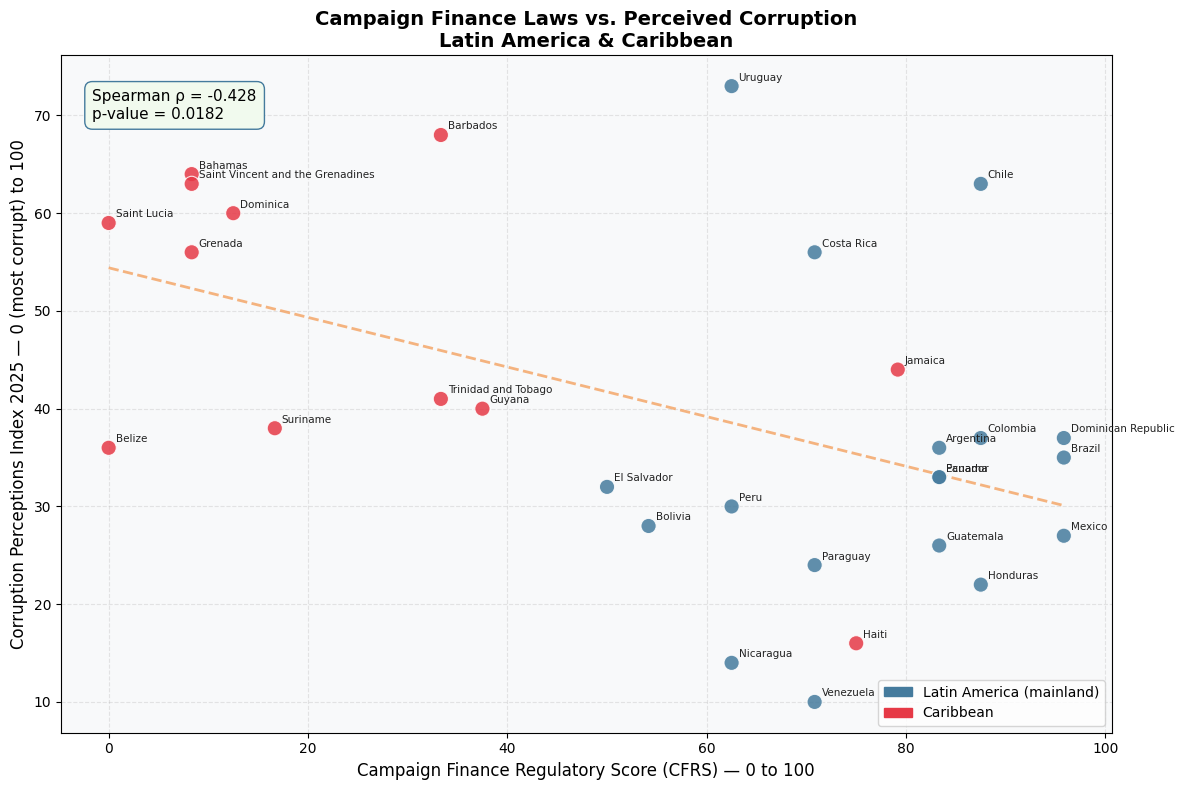

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

caribbean = ['Antigua and Barbuda','Bahamas','Barbados','Belize','Cuba','Dominica',
             'Grenada','Guyana','Haiti','Jamaica','Saint Kitts and Nevis','Saint Lucia',
             'Saint Vincent and the Grenadines','Suriname','Trinidad and Tobago']

colors = merged['Country'].apply(lambda c: '#E63946' if c in caribbean else '#457B9D')

ax.scatter(merged['CFRS_scaled'], merged['CPI_2025'],
           c=colors, s=120, alpha=0.85, edgecolors='white', linewidth=0.8, zorder=3)

for _, row in merged.iterrows():
    ax.annotate(row['Country'],
                xy=(row['CFRS_scaled'], row['CPI_2025']),
                xytext=(5, 4), textcoords='offset points',
                fontsize=7.5, color='#222222')

m, b = np.polyfit(merged['CFRS_scaled'], merged['CPI_2025'], 1)
x_line = np.linspace(merged['CFRS_scaled'].min(), merged['CFRS_scaled'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#F4A261', linewidth=2, linestyle='--', alpha=0.8)

ax.text(0.03, 0.95, f"Spearman ρ = {rho:.3f}\np-value = {pval:.4f}",
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F1FAEE', edgecolor='#457B9D'))

latam_patch    = mpatches.Patch(color='#457B9D', label='Latin America (mainland)')
caribbean_patch = mpatches.Patch(color='#E63946', label='Caribbean')
ax.legend(handles=[latam_patch, caribbean_patch], loc='lower right', fontsize=10)

ax.set_xlabel('Campaign Finance Regulatory Score (CFRS) — 0 to 100', fontsize=12)
ax.set_ylabel('Corruption Perceptions Index 2025 — 0 (most corrupt) to 100', fontsize=12)
ax.set_title('Campaign Finance Laws vs. Perceived Corruption\nLatin America & Caribbean', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.show()

## 5. Key Findings

- **Spearman ρ = -0.428** indicates a moderate *negative* correlation between CFRS and CPI scores
- Countries with *more* campaign finance laws tend to score *lower* on the corruption perception index
- This reflects **reactive legislation** — countries with higher corruption are more likely to have passed reform laws in response to public pressure
- Caribbean small island states cluster top-left — low regulatory scores but relatively higher CPI, likely due to simpler political economies
- **Chile and Uruguay** stand out as strongest performers on both dimensions — strong laws *and* lower perceived corruption

## 6. Limitations & Next Steps

- CPI measures *perceptions* of corruption, not actual corruption
- IDEA data reflects laws on paper, not enforcement quality
- Future work: add World Bank Control of Corruption index, GDP per capita as a control variable, and a press freedom score
- Sample size (n=30) limits statistical power — findings are suggestive, not definitive